In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/dataset.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1965,3948-XHGNA,Male,0,No,No,24,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),49.55,1210.4,Yes
2007,8086-OVPWV,Male,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,80.20,181.1,Yes
544,2817-NTQDO,Male,0,No,No,13,No,No phone service,DSL,Yes,...,No,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),45.55,597,Yes
1564,2660-EMUBI,Male,1,No,No,10,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.35,898.35,Yes
957,8388-FYNPZ,Male,0,No,No,4,Yes,No,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Electronic check,56.75,245.15,No


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.loc[df["TotalCharges"].isnull(), "TotalCharges"] = 0

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
df = df.drop(columns="customerID" , axis=1)

In [13]:
df["SeniorCitizen"] = df["SeniorCitizen"].astype(np.int16)

In [14]:
df["tenure"] = df["tenure"].astype(np.int16)

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [16]:
df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

In [17]:
for col in df.columns:
    print(col, df[col].nunique())

gender 2
SeniorCitizen 2
Partner 2
Dependents 2
tenure 73
PhoneService 2
MultipleLines 3
InternetService 3
OnlineSecurity 3
OnlineBackup 3
DeviceProtection 3
TechSupport 3
StreamingTV 3
StreamingMovies 3
Contract 3
PaperlessBilling 2
PaymentMethod 4
MonthlyCharges 1585
TotalCharges 6530
Churn 2


In [18]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [55]:
def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n")

for col in df.select_dtypes(np.number).columns:
    target_summary_with_num(df, "Churn", col)


       SeniorCitizen
Churn               
0           0.128721
1           0.254682

          tenure
Churn           
0      37.569965
1      17.979133

       MonthlyCharges
Churn                
0           61.265124
1           74.441332

       TotalCharges
Churn              
0       2555.344141
1       1531.796094

       Churn
Churn       
0        0.0
1        1.0



In [57]:
def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"CHURN_MEAN": dataframe.groupby(categorical_col)[target].mean()}))


for col in df.select_dtypes("object").columns:
    target_summary_with_cat(df, "Churn", col)

        CHURN_MEAN
gender            
Female    0.269209
Male      0.261603
         CHURN_MEAN
Partner            
No         0.329580
Yes        0.196649
            CHURN_MEAN
Dependents            
No            0.312791
Yes           0.154502
              CHURN_MEAN
PhoneService            
No              0.249267
Yes             0.267096
                  CHURN_MEAN
MultipleLines               
No                  0.250442
No phone service    0.249267
Yes                 0.286099
                 CHURN_MEAN
InternetService            
DSL                0.189591
Fiber optic        0.418928
No                 0.074050
                     CHURN_MEAN
OnlineSecurity                 
No                     0.417667
No internet service    0.074050
Yes                    0.146112
                     CHURN_MEAN
OnlineBackup                   
No                     0.399288
No internet service    0.074050
Yes                    0.215315
                     CHURN_MEAN
DeviceProtectio

1] Gender has very little influence on churn.

2] Customers with partners are more stable and less likely to churn.

3] Customers with dependents are significantly more loyal.

4] Fiber users churn:
* more than 2x DSL users
* almost 6x no-internet users

Fiber optic customers exhibit the highest churn rate (41.9%), suggesting dissatisfaction among premium internet users despite higher-priced service offerings.

5] Support-related services drastically reduce churn.

6] Why do electronic check users churn so much?

Possible reasons:

* payment friction
* failed transactions
* lower customer commitment
* financially unstable segment

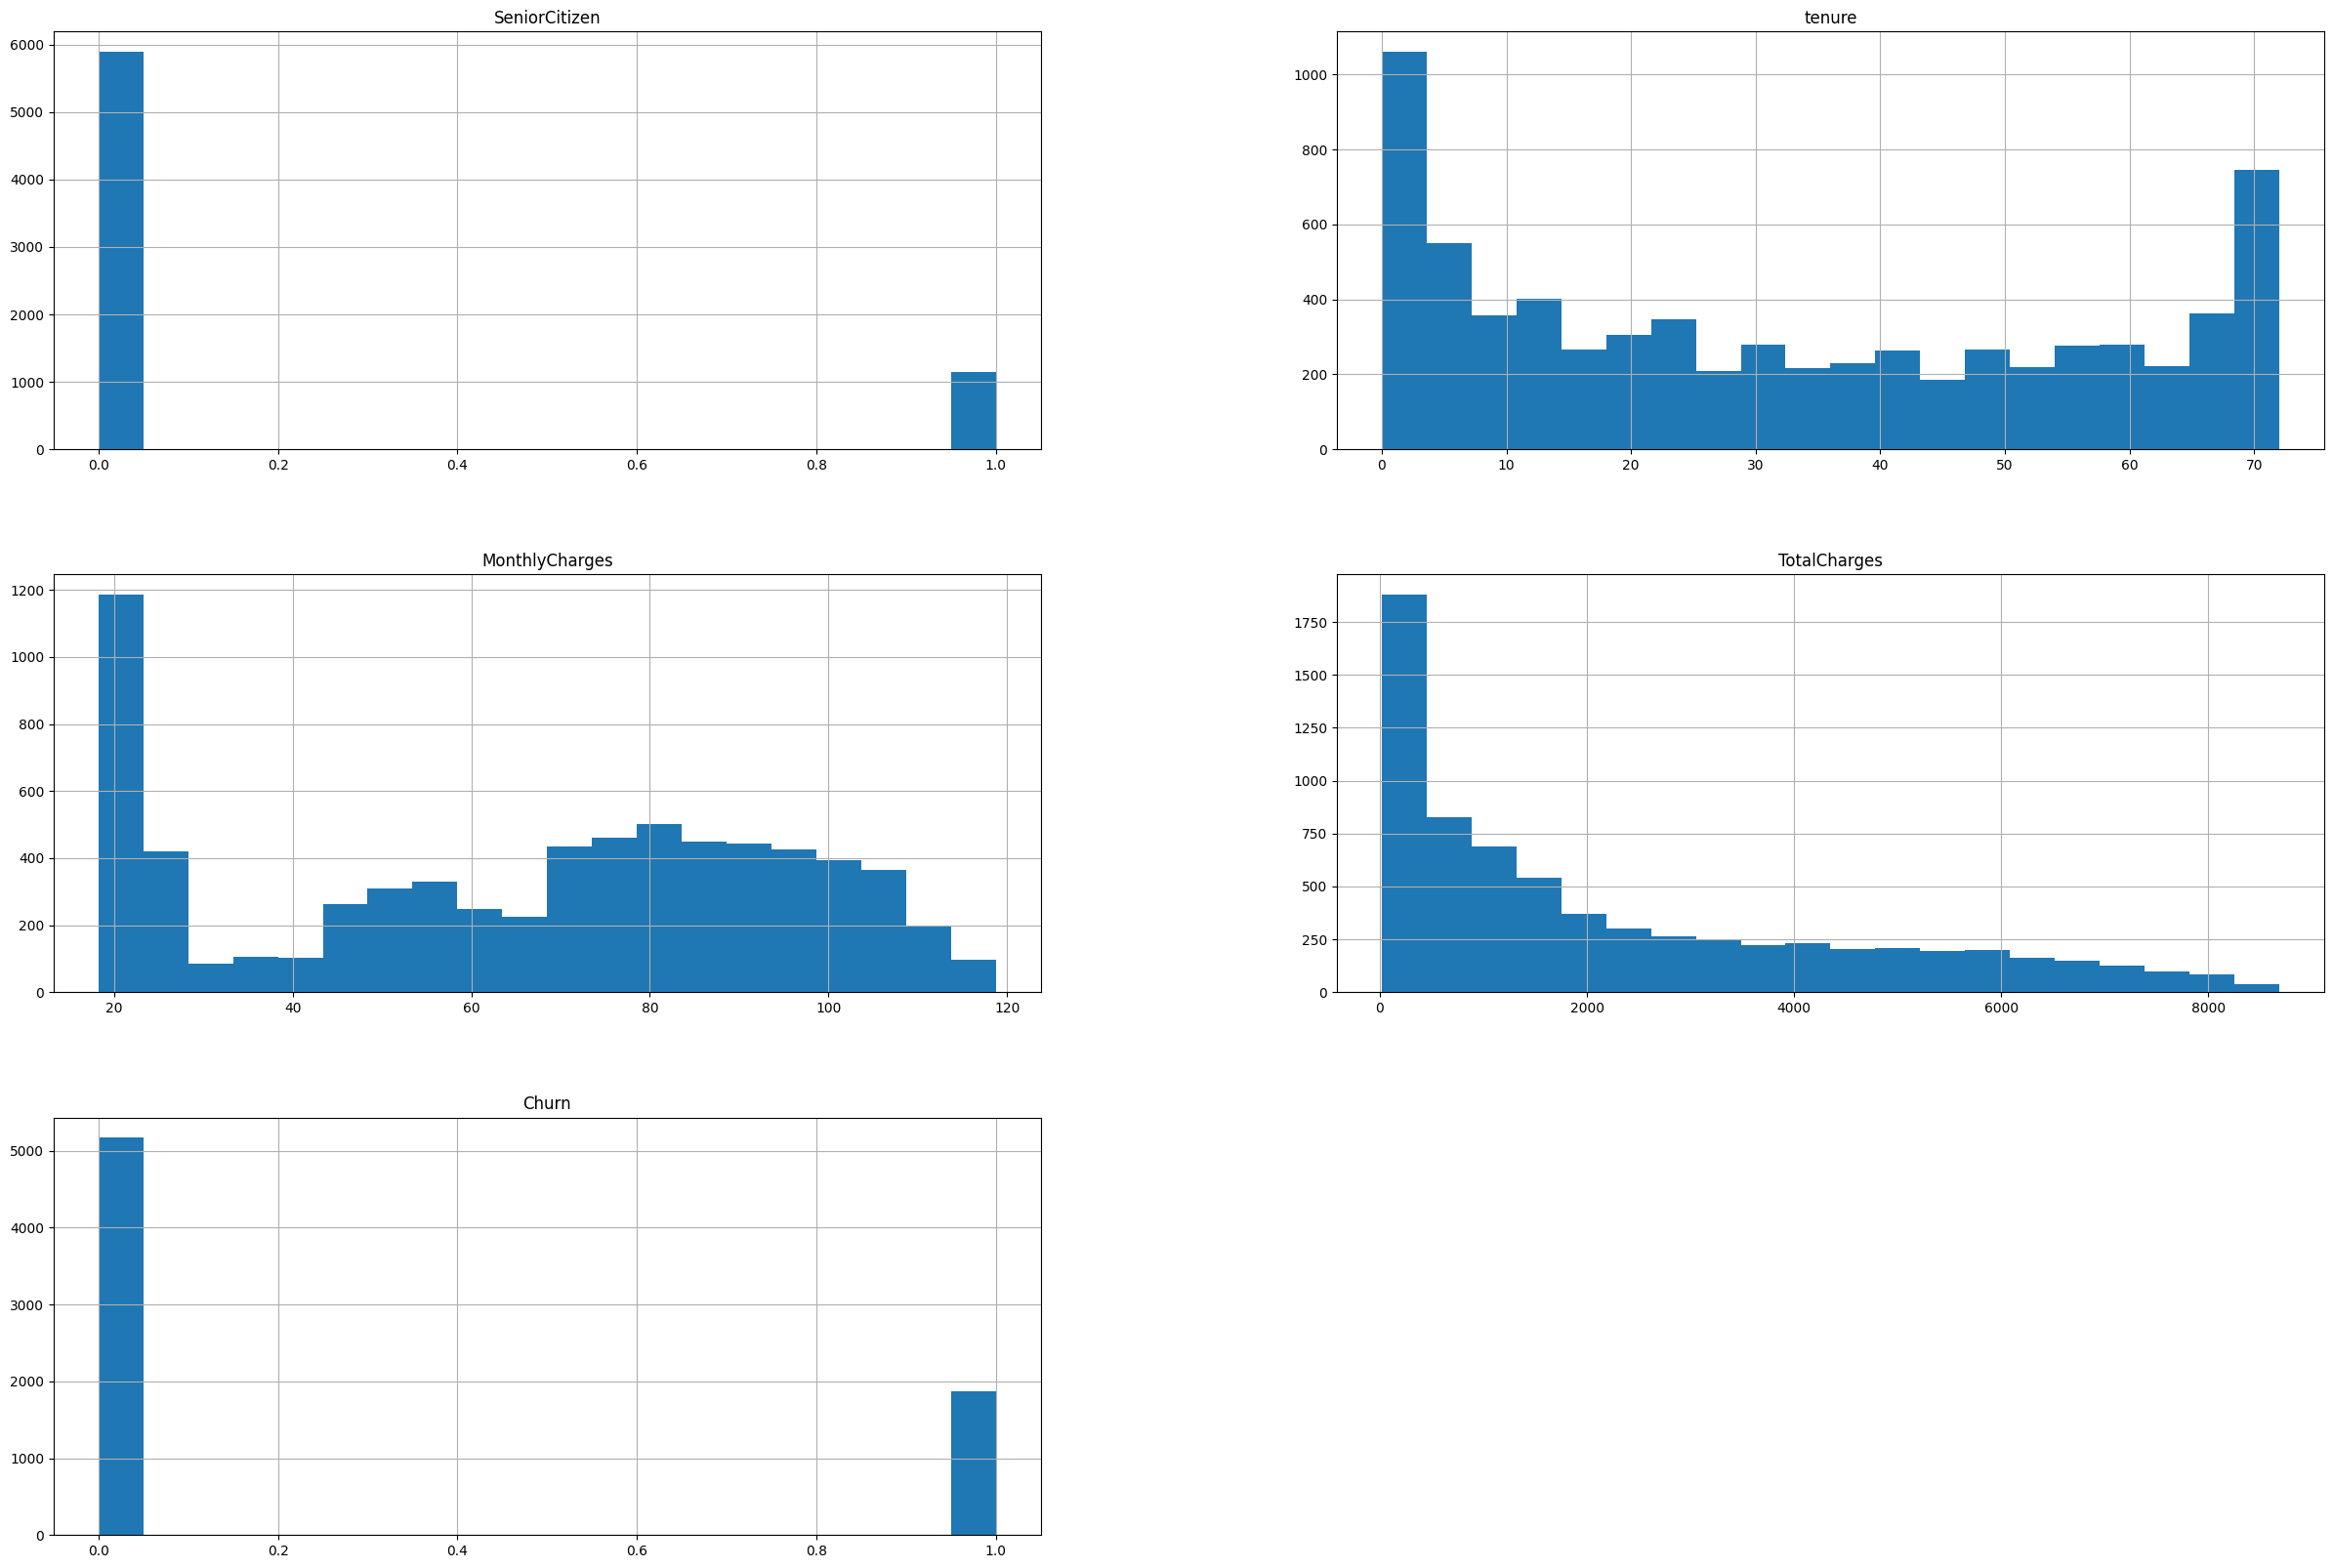

In [58]:
num_bins = 20
df.hist(bins=num_bins, figsize=(30,20))
plt.show()

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

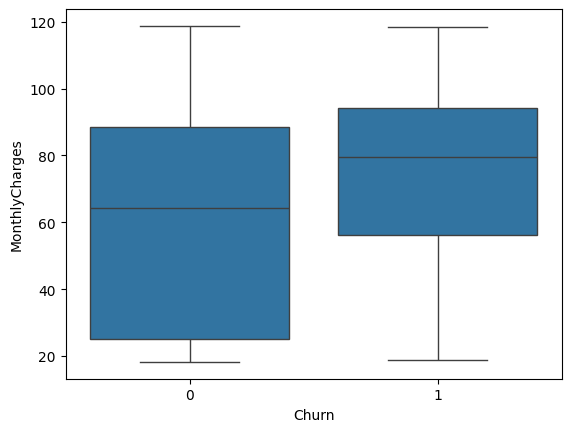

In [20]:
sns.boxplot(y=df['MonthlyCharges'] , x = df["Churn"])

#### people with high monthly charges are the one who are leaving more

<Axes: xlabel='Contract', ylabel='count'>

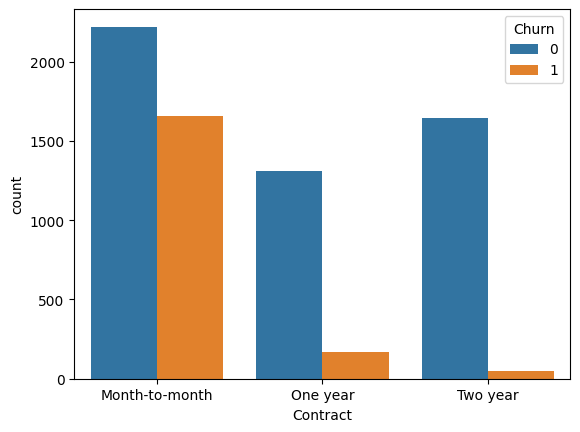

In [21]:
sns.countplot(x='Contract',hue="Churn" ,data=df)

###  people with month to month contract are those who are churning more

<Axes: xlabel='Churn', ylabel='TotalCharges'>

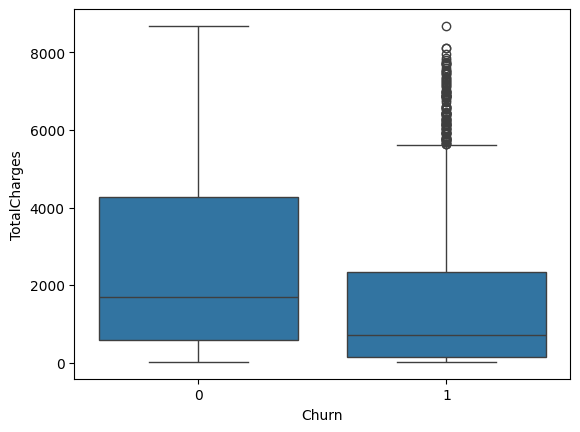

In [22]:
sns.boxplot(x="Churn" , y="TotalCharges" , data=df)

Customers who churned generally exhibit significantly lower TotalCharges compared to retained customers, indicating that newer or less-engaged customers are more likely to leave the service. However, the presence of high-value churn outliers suggests that even customers with substantial historical spending may churn due to dissatisfaction or competitive alternatives.

<Axes: xlabel='Churn', ylabel='tenure'>

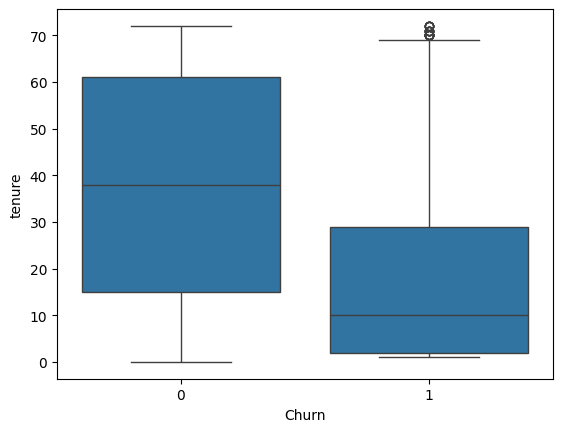

In [23]:
sns.boxplot(x='Churn', y='tenure', data=df)

#### Lower tenure → Higher churn

In [24]:
pd.crosstab(df['gender'], df['Churn'], normalize='index')

Churn,0,1
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


In [25]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')

Churn,0,1
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [26]:
# ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
#      'tenure', 'PhoneService', 'MultipleLines', 'InternetService'
# 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
#        'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
#        'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'

In [27]:
pd.crosstab(df['Partner'], df['Churn'], normalize='index')

Churn,0,1
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649


<Axes: xlabel='Dependents', ylabel='count'>

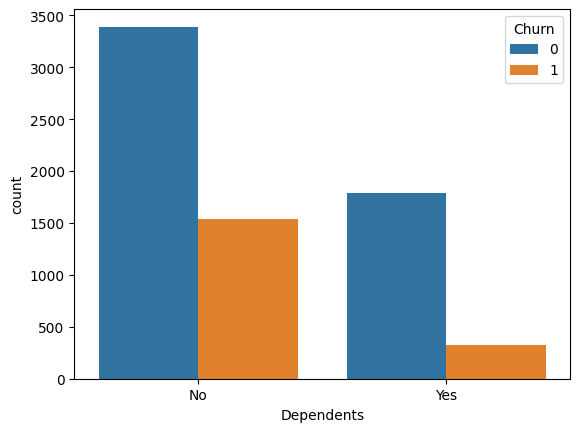

In [28]:
sns.countplot(x=df['Dependents'] , hue=df["Churn"])

In [29]:
df.corr(numeric_only=True)["Churn"].sort_values()

tenure           -0.352229
TotalCharges     -0.199484
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Churn             1.000000
Name: Churn, dtype: float64

In [30]:
df.groupby(["Churn","SeniorCitizen"])["gender"].count()

Churn  SeniorCitizen
0      0                4508
       1                 666
1      0                1393
       1                 476
Name: gender, dtype: int64

#### seniorCitizen analysis why there are leaving??


In [31]:
temp = df[(df["SeniorCitizen"]==1) & (df["Churn"]==1) ]

In [32]:
temp.groupby("InternetService")["gender"].count()

InternetService
DSL             78
Fiber optic    393
No               5
Name: gender, dtype: int64

In [33]:
temp.groupby("TechSupport")["gender"].count()

TechSupport
No                     420
No internet service      5
Yes                     51
Name: gender, dtype: int64

In [34]:
temp.groupby("Contract")["gender"].count()

Contract
Month-to-month    441
One year           29
Two year            6
Name: gender, dtype: int64

In [35]:
temp.groupby("PaperlessBilling")["gender"].count()

PaperlessBilling
No      78
Yes    398
Name: gender, dtype: int64

<Axes: ylabel='TotalCharges'>

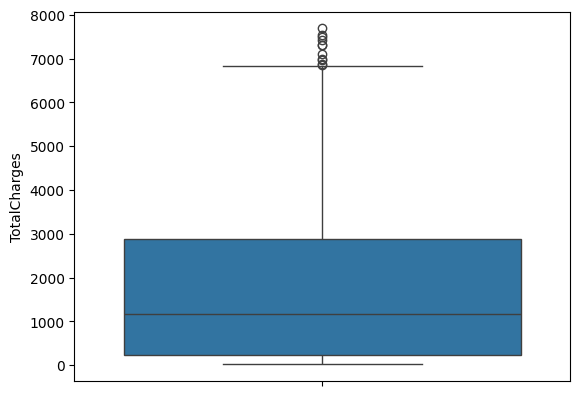

In [36]:
sns.boxplot(temp["TotalCharges"])

In [37]:
pd.crosstab(
    [df['SeniorCitizen'], df['Contract']],
    df['Churn'],
    normalize='index'
)

Churn                                0         1
SeniorCitizen Contract                          
0             Month-to-month  0.604302  0.395698
              One year        0.893219  0.106781
              Two year        0.972903  0.027097
1             Month-to-month  0.453532  0.546468
              One year        0.847368  0.152632
              Two year        0.958621  0.041379

Senior citizens exhibit a substantially higher churn rate (41.7%) compared to non-senior customers (23.6%). This suggests that older customers may face greater dissatisfaction, pricing concerns, or support-related challenges, making them a high-risk customer segment.

1]senior citizens lack tech support

2]they use month-to-month contracts more

3]their monthly charges are higher

## #Customer with higher  totalCharges and tenure but still they are leaving 

In [38]:
Q1 = df[df["Churn"]==1]['TotalCharges'].quantile(0.25)
Q3 = df[df["Churn"]==1]['TotalCharges'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['TotalCharges'] > upper_bound) &
    (df["Churn"]==1)
]

print(outliers.shape)
outliers.head()

(109, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
104,Male,0,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.00,7611.85,1
339,Male,0,Yes,No,63,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.40,6603.00,1
402,Male,0,Yes,Yes,69,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.45,7007.60,1
445,Female,0,No,No,60,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,6396.45,1
609,Female,1,Yes,No,65,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),105.25,6786.40,1


In [39]:
outliers.groupby("InternetService")["gender"].count()

InternetService
DSL              1
Fiber optic    108
Name: gender, dtype: int64

<Axes: xlabel='MonthlyCharges'>

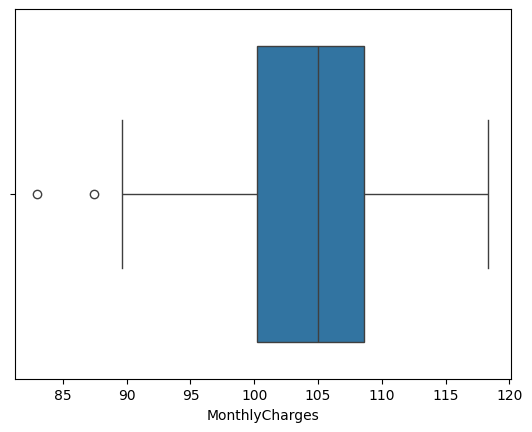

In [40]:
sns.boxplot(x = "MonthlyCharges" , data=outliers)

A significant portion of high-value churned customers belong to the fiber optic segment and exhibit high monthly charges, suggesting dissatisfaction among premium customers despite substantial historical spending.

## High Risk Segment

In [69]:
df.groupby(
    ['InternetService', 'Contract', 'TechSupport']
)['Churn'].mean().sort_values(ascending = False)

InternetService  Contract        TechSupport        
Fiber optic      Month-to-month  No                     0.575167
                                 Yes                    0.388554
DSL              Month-to-month  No                     0.358597
                                 Yes                    0.227139
Fiber optic      One year        Yes                    0.203540
No               Month-to-month  No internet service    0.188931
Fiber optic      One year        No                     0.185304
DSL              One year        No                     0.098361
                                 Yes                    0.088957
Fiber optic      Two year        No                     0.082645
                                 Yes                    0.068182
DSL              Two year        No                     0.034783
No               One year        No internet service    0.024725
DSL              Two year        Yes                    0.015595
No               Two year        No i

Customers using premium fiber optic internet services with month-to-month contracts and lacking tech support exhibit the highest churn risk, with churn rates exceeding 57%. In contrast, long-term contract users and customers receiving support services demonstrate significantly lower churn rates, indicating that customer commitment and support quality are critical drivers of retention.




#### How much revenue comes from high-risk segments?

In [78]:
high_risk = df[
    (df['InternetService'] == 'Fiber optic') &
    (df['Contract'] == 'Month-to-month') &
    (df['TechSupport'] == 'No')
]

high_risk_revenue=high_risk['MonthlyCharges'].sum()
revenue = df['MonthlyCharges'].sum()

print((high_risk_revenue*100)/revenue,"%")


33.66390304584398 %


Approximately 33.66% of total revenue comes from the high-risk churn customer segment.

Insight                         ----------->             Recommendation

Fiber + Month-to-month high churn----------->           promote annual contracts

No TechSupport high churn    ----------->               offer free support trial

Premium users leaving        --------->                improve premium service quality